# Problem formulation

1) combining these three: Variable-speed OPTW with SOCP energy model and time-dependent information rewards. 

2) Physical calibration: Mapping Solomon benchmarks to a real UAV platform (TB2) with speed-dependent power consumption.

3) Experimental design — Slope regimes, eta sensitivity, loitering value, speed adaptation. These tell a story about how information dynamics change solution structure.

4) Practical relevance — surveillance UAV routing is timely with real applications.

5) Dataset with +200 nodes for local search?

# Exact Solver Experiments (Campaign-Time Calibration)

All experiments use campaign-time calibration with η parameter for energy scaling.
Three slope regimes: random, positive, zero.

**Datasets:** C101 (50), R101 (50), RC101 (100), R101 (100).
Baseline solve times: C101-50 ~4s, R101-50 ~2s, RC101-100 ~600s, R101-100 ~49s.

## Run times

| Section | Solves | Estimate |
|---------|--------|----------|
| 1. Scalability (4 datasets) | 4 | ~11m |
| 2. Slope comparison (2×50-node × 3 slopes) | 6 | ~20m 20s |
| 3. Gap convergence (R101-50 × 3 slopes) | 3 | ~20m 20s |
| 4. Eta sweep (2×50-node × 5 η) | 10 | ~22m 45s |
| 5. Value of loitering (R101-50 × 5 η × 2) | 10 | ~3m 20s |
| 6. Speed by η (R101-50 × 3 η) | 3 | ~1m 16s |
| 7. Arrival time by slope (R101-50 × 3) | 3 | ~15s |
| 8. Single detailed run (R101-50) | 1 | ~3s |
| 9. Reproducibility (R101-50 × 5 seeds) | 5 | ~28s |
| **Total** | **45** | **~** |

In [14]:
from uav_routing.environment import Environment
from uav_routing.environment.calibration import calibrate, calibration_info
from uav_routing.environment.graph import Graph
from uav_routing.environment.drone import Drone
from uav_routing.solver.exact import solve_model_gurobi, print_table
from uav_routing.solver.analysis import (
    eta_sensitivity, arrival_time_histogram, speed_histogram,
    speed_histogram_by_eta, scalability_table, value_of_loitering,
    gap_convergence_plot
)
import gurobipy as gp
import pandas as pd

# Dataset paths
datasets = {
    "C101 (50)":  "../datasets/data/50_c101.txt",
    "R101 (50)":  "../datasets/data/50_r101.txt",
    "RC101 (100)":"../datasets/data/rc101.txt",
    "R101 (100)": "../datasets/data/r101.txt",
}

# Common parameters
SEED = 42
TIME_LIMIT = 600
SORTIE_TIME = 3.0

def make_instance(path, slope='random', graph_seed=1, eta=1.0):
    """Create a campaign-calibrated instance."""
    graph = Graph(path=path, slope=slope, seed=graph_seed)
    uav = Drone(base=graph.graph['base'])
    calib = calibrate(
        graph=graph,
        tour_length=len(graph.nodes) // 2,
        drone=uav,
        drone_sortie_time=SORTIE_TIME,
        calibration_method="campaign",
    )
    return Environment(calib, uav, eta=eta), graph, uav

## 1. Scalability Table

Solve all datasets with campaign-time calibration (eta=1, random slopes).
Report: nodes, objective, gap, solve time, tour length.

**Settings:** $\eta = 1$, random slopes, campaign-time calibration, $T_\text{sortie} = 3$h, time limit = 600s.

**Purpose:** Establish baseline performance and identify which instances the exact solver can close within the time limit. 50-node instances should solve to optimality; 100-node instances will likely hit the time limit with a nonzero gap. This motivates the need for heuristics on larger instances.

In [2]:
rows = []
with gp.Env(empty=True) as env:
    env.setParam('OutputFlag', 0)
    env.start()

    for name, path in datasets.items():
        instance, graph, uav = make_instance(path)
        print(f"\n{'='*60}")
        print(f"Solving {name}...")
        res = solve_model_gurobi(instance, seed=SEED, time_limit=TIME_LIMIT,
                                 env=env, prune=False, stats=False)

        energy_util = "-"
        if res and res.get("arc_data"):
            total_energy = sum(
                uav.socp_energy_function(ad['t'], ad['y'], ad['z'])
                for ad in res['arc_data'].values()
            )
            energy_util = f"{total_energy / instance.max_energy * 100:.2f}"

        rows.append({
            "Instance": name,
            "Nodes": len(graph.nodes),
            "Objective": round(res["obj"], 2) if res and res.get("obj") else None,
            "Gap (%)": f"{res['gap']*100:.2f}" if res and res.get("gap") is not None else "-",
            "Time (s)": round(res["solve_time"], 1) if res and res.get("solve_time") else "-",
            "Tour nodes": len(res["tour"]) - 2 if res and res.get("tour") else 0,
            "Energy util (%)": energy_util,
        })
        if res and res.get("tour"):
            print_table(instance, res)

df_scale = pd.DataFrame(rows)
print(f"\n{'='*60}")
print("SUMMARY")
df_scale


Solving C101 (50)...

--- Gurobi Solver Report ---
      Edge  Total Time (s)  Loiter Time (s)  Speed (m/s)  SOCP Energy (J)  Real Energy (J)  Energy %  Arrival Time (s)      Time Window     Slope
     0->20           87.38             0.00        44.31       2208756.15       1376363.54    0.8091             87.38    [87.4, 637.9] -1.316378
    20->32          183.50             0.00        47.18       3098336.63       3101807.07    1.8233            270.87   [270.9, 873.8] -2.136742
    32->42          323.30            36.60        32.89       4468237.01       4472558.40    2.6291            594.17  [594.2, 1301.9] -1.635858
    42->33          166.60             0.00        61.00       4374364.10       4375809.61    2.5722            760.78  [760.2, 1380.6] -0.397723
    33->17          532.42           111.08        33.45       7357154.82       7359972.54    4.3264           1293.20  [865.0, 1293.2]  3.176094
    17->25          183.50             0.00        50.73       3420278.9

,Instance,Nodes,Objective,Gap (%),Time (s),Tour nodes,Energy util (%)
0,C101 (50),51,14669.20,0.00,4.0,33,100.00
1,R101 (50),51,144232.37,0.00,2.4,6,100.00
2,RC101 (100),101,230962.82,77.25,600.0,9,100.00
3,R101 (100),101,293439.33,0.00,49.2,12,100.00


## 2. Slope Regime Comparison

Compare random, positive, and zero slopes on the same instance.
- Random: mixed decay/growth (breaks timing symmetry)
- Positive: growth only (all nodes reward late arrival)
- Zero: static info (classical OP — massive solver symmetry)

**Settings:** $\eta = 1$, campaign-time calibration, time limit = 600s.

**Purpose:** Demonstrate the impact of information dynamics on solver difficulty:
- **Positive slopes** (growth only): all nodes reward late arrival, giving the solver a single dominant strategy. Expected: fastest convergence, tightest gap.
- **Zero slopes** (static info): classical orienteering — arrival time is irrelevant, creating symmetry in branch-and-bound. Expected: moderate difficulty.
- **Random slopes** (mixed $\pm\gamma$): each node has a different timing preference, creating complex per-node trade-offs that multiply the search space. Expected: slowest convergence, largest gap.

In [3]:
# Run on 50-node instances (solvable within time limit)
slope_test_datasets = {
    "C101 (50)": datasets["C101 (50)"],
    "R101 (50)": datasets["R101 (50)"],
}

slope_rows = []
with gp.Env(empty=True) as env:
    env.setParam('OutputFlag', 0)
    env.start()

    for name, path in slope_test_datasets.items():
        for slope in ['random', 'positive', 'zero']:
            print(f"\n{'='*60}")
            print(f"Solving {name} | slope={slope}...")
            instance, graph, uav = make_instance(path, slope=slope)
            res = solve_model_gurobi(instance, seed=SEED, time_limit=TIME_LIMIT,
                                     env=env, prune=False, stats=False)
            slope_rows.append({
                "Instance": name,
                "Slope": slope,
                "Objective": round(res["obj"], 2) if res and res.get("obj") else None,
                "Gap (%)": f"{res['gap']*100:.2f}" if res and res.get("gap") is not None else "-",
                "Time (s)": round(res["solve_time"], 1) if res and res.get("solve_time") else "-",
                "Tour nodes": len(res["tour"]) - 2 if res and res.get("tour") else 0,
            })
            if res and res.get("tour"):
                print_table(instance, res)

df_slopes = pd.DataFrame(slope_rows)
print(f"\n{'='*60}")
print("SUMMARY")
df_slopes


Solving C101 (50) | slope=random...

--- Gurobi Solver Report ---
      Edge  Total Time (s)  Loiter Time (s)  Speed (m/s)  SOCP Energy (J)  Real Energy (J)  Energy %  Arrival Time (s)      Time Window     Slope
     0->20           87.38             0.00        44.31       2208756.15       1376363.54    0.8091             87.38    [87.4, 637.9] -1.316378
    20->32          183.50             0.00        47.18       3098336.63       3101807.07    1.8233            270.87   [270.9, 873.8] -2.136742
    32->42          323.30            36.60        32.89       4468237.01       4472558.40    2.6291            594.17  [594.2, 1301.9] -1.635858
    42->33          166.60             0.00        61.00       4374364.10       4375809.61    2.5722            760.78  [760.2, 1380.6] -0.397723
    33->17          532.42           111.08        33.45       7357154.82       7359972.54    4.3264           1293.20  [865.0, 1293.2]  3.176094
    17->25          183.50             0.00        50.73 

,Instance,Slope,Objective,Gap (%),Time (s),Tour nodes
0,C101 (50),random,14669.20,0.00,4.3,33
1,C101 (50),positive,25473.29,2.05,600.0,38
2,C101 (50),zero,820.00,4.88,600.0,46
3,R101 (50),random,144232.37,0.00,2.8,6
4,R101 (50),positive,211603.09,0.00,10.0,9
5,R101 (50),zero,208.00,0.00,2.2,10


## 3. Gap Convergence Plot (Slope Impact)

MIP gap vs solve time for random, positive, and zero slopes.
Shows that slopes break symmetry and improve solver tractability.

**Expected output: Figure 1 — Gap convergence curves (side by side)**

Two panels: C101 (50) and R101 (50), each with three curves (random, positive, zero) showing MIP gap (%) vs solve time (s).

**Purpose:** Visualize how slopes and instance geometry interact:
- **C101 (clustered):** Zero slopes + clustered nodes create massive symmetry — expect the slowest gap convergence. Positive slopes give a uniform "arrive late" strategy that helps pruning.
- **R101 (random):** Random geometry already breaks symmetry, so slope effects are less dramatic. Positive slopes still converge fastest (single dominant strategy).
- **Across both:** Random slopes create complex per-node trade-offs (some nodes want early, some late), making branch-and-bound harder.

This figure supports the argument that information dynamics interact with instance geometry to affect solver tractability.

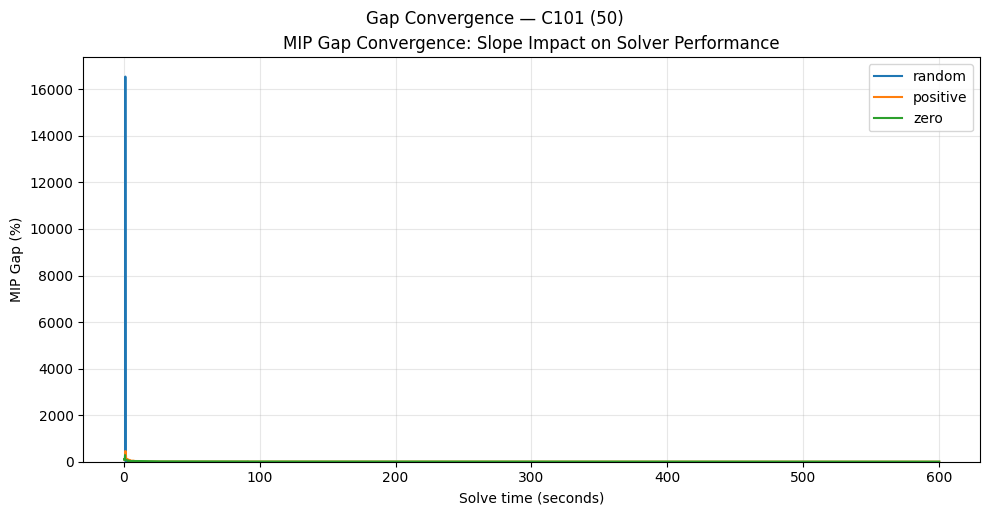

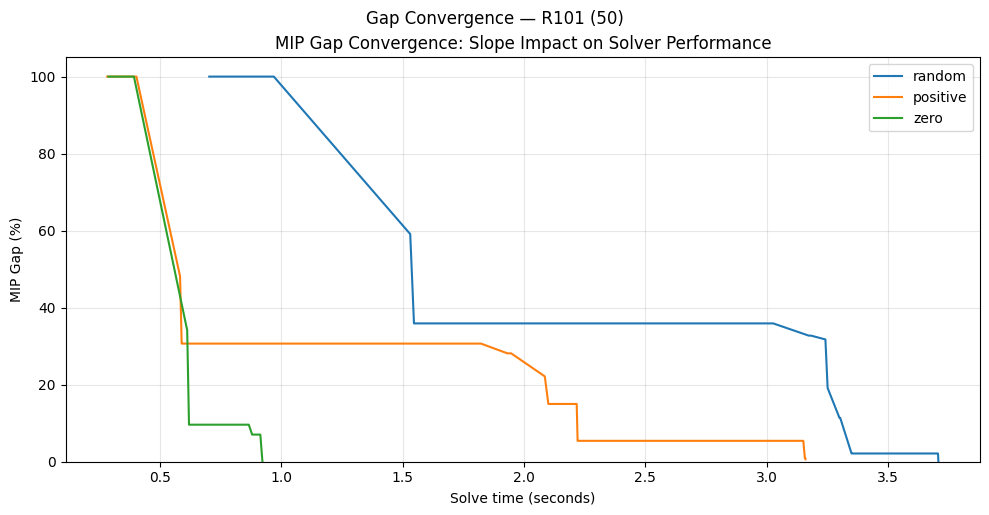

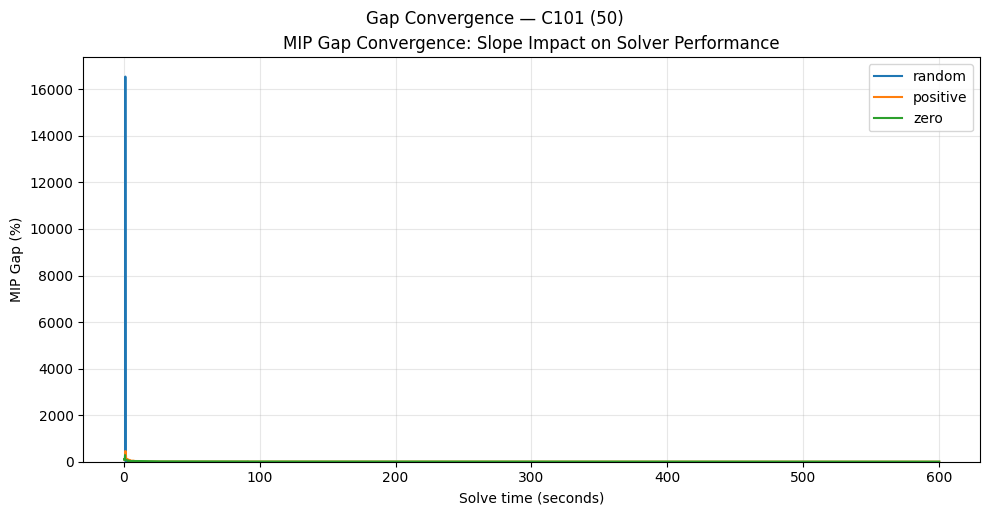

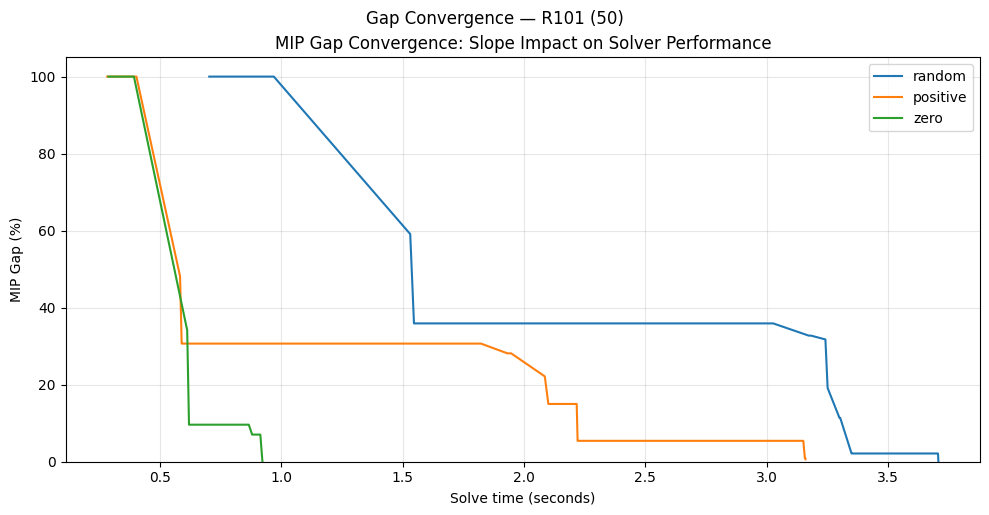

In [16]:
figs = []
for name, path in slope_test_datasets.items():
    instance_ref, _, _ = make_instance(path, slope='random')
    slope_configs = [
        ('random', Graph(path=path, slope='random', seed=1)),
        ('positive', Graph(path=path, slope='positive', seed=1)),
        ('zero', Graph(path=path, slope='zero', seed=1)),
    ]
    with gp.Env(empty=True) as env:
        env.setParam('OutputFlag', 0)
        env.start()
        fig = gap_convergence_plot(instance_ref, env, seed=SEED,
                                    time_limit=TIME_LIMIT, slope_configs=slope_configs)
        fig.suptitle(f'Gap Convergence — {name}', y=1.02)
        figs.append(fig)

for f in figs:
    display(f)

## 4. Energy Sensitivity (eta sweep)

Sweep eta in {0.5, 0.75, 1.0, 1.25, 1.5} to study the energy-time trade-off.
eta=1 means full sortie energy; eta<1 tightens the energy constraint.

**Settings:** Random slopes, campaign-time calibration, time limit = 600s.

**Purpose:** Study the energy–information trade-off. As $\eta$ decreases:
- Fewer nodes can be visited (shorter tours).
- Energy utilization should approach 100% (the constraint becomes binding).
- The solver should find optimal solutions faster (smaller feasible region).
- The objective should degrade gracefully — a steep drop indicates that the energy constraint is highly restrictive.

This experiment is analogous to Tural et al.'s energy budget grid but with a single parameter $\eta$ instead of separate time and energy budgets.

In [5]:
# Eta sweep on 50-node instances
eta_test_datasets = {
    "C101 (50)": datasets["C101 (50)"],
    "R101 (50)": datasets["R101 (50)"],
}

eta_values = (0.6, 0.75, 1.0, 1.25, 1.50)
eta_rows = []

with gp.Env(empty=True) as env:
    env.setParam('OutputFlag', 0)
    env.start()

    for name, path in eta_test_datasets.items():
        for eta in eta_values:
            instance, _, _ = make_instance(path, eta=eta)
            print(f"\n{'='*60}")
            print(f"{name} | eta={eta}")
            res = solve_model_gurobi(instance, seed=SEED, time_limit=TIME_LIMIT,
                                     env=env, prune=False, stats=False)
            eta_rows.append({
                "Instance": name,
                "eta": eta,
                "Objective": round(res["obj"], 2) if res and res.get("obj") else None,
                "Gap (%)": f"{res['gap']*100:.2f}" if res and res.get("gap") is not None else "-",
                "Time (s)": round(res["solve_time"], 1) if res and res.get("solve_time") else "-",
                "Tour nodes": len(res["tour"]) - 2 if res and res.get("tour") else 0,
            })
            if res and res.get("tour"):
                print_table(instance, res)

df_eta = pd.DataFrame(eta_rows)
print(f"\n{'='*60}")
print("SUMMARY")
df_eta


C101 (50) | eta=0.6

--- Gurobi Solver Report ---
      Edge  Total Time (s)  Loiter Time (s)  Speed (m/s)  SOCP Energy (J)  Real Energy (J)  Energy %  Arrival Time (s)      Time Window     Slope
     0->20           87.38             0.00        44.31       1369144.45       1376363.54    1.3484             87.38    [87.4, 637.9] -1.316378
    20->32          183.50             0.00        47.18       3101200.61       3101807.07    3.0389            270.87   [270.9, 873.8] -2.136742
    32->24          297.09            92.57        34.13       4104597.68       4107632.45    4.0243            567.96  [568.0, 1258.3] -0.626915
    24->33          192.23             0.00        39.72       2778356.60       2779873.91    2.7235            760.19  [760.2, 1380.6] -0.397723
    33->17          533.01           114.93        33.71       7364493.73       7367578.34    7.2181           1293.20  [865.0, 1293.2]  3.176094
    17->25          183.50             0.00        50.73       3427531.82

,Instance,eta,Objective,Gap (%),Time (s),Tour nodes
0,C101 (50),0.60,11034.70,19.70,600.0,20
1,C101 (50),0.75,13928.62,2.35,600.0,24
2,C101 (50),1.00,14669.20,0.00,4.5,33
3,C101 (50),1.25,14669.20,0.00,4.1,33
4,C101 (50),1.50,14669.20,0.00,5.1,33
5,R101 (50),0.60,79937.04,0.00,61.6,4
6,R101 (50),0.75,91339.87,0.00,62.6,5
7,R101 (50),1.00,144232.37,0.00,2.5,6
8,R101 (50),1.25,144625.34,0.00,12.4,7
9,R101 (50),1.50,144625.34,0.00,9.0,7


## 5. Value of Loitering

Compare full model (L >= d, loitering allowed) vs no-loiter model (L = d).
Quantifies objective gain from speed flexibility across eta values.

**Settings:** R101 (50), random slopes, campaign-time calibration, time limit = 600s.

**Purpose:** Quantify the value of variable-speed flight (loitering). The full model allows $L_{ij} \geq d_{ij}$ (the drone can fly slower than optimal to spend more time in transit and adjust arrival timing). The no-loiter model forces $L_{ij} = d_{ij}$. The gain measures how much the objective improves when the drone has speed flexibility. Expected:
- At tight $\eta$, loitering gain is small (energy is the bottleneck, not timing).
- At loose $\eta$, loitering gain is significant (the drone uses excess energy to optimize arrival times).
- This validates a core model feature: variable-speed flight is not just a theoretical extension but produces measurable information gain.

In [6]:
eta_values = (0.6, 0.75, 1.0, 1.25, 1.50)
loiter_rows = []

with gp.Env(empty=True) as env:
    env.setParam('OutputFlag', 0)
    env.start()

    for eta in eta_values:
        instance, _, _ = make_instance(datasets["R101 (50)"], eta=eta)

        print(f"\n{'='*60}")
        print(f"R101 (50) | eta={eta} | FULL MODEL (loitering allowed)")
        res_full = solve_model_gurobi(instance, seed=SEED, time_limit=TIME_LIMIT,
                                      env=env, prune=False, stats=False, no_loiter=False)
        if res_full and res_full.get("tour"):
            print_table(instance, res_full)

        print(f"\n{'-'*60}")
        print(f"R101 (50) | eta={eta} | NO-LOITER (L = d)")
        res_nol = solve_model_gurobi(instance, seed=SEED, time_limit=TIME_LIMIT,
                                     env=env, prune=False, stats=False, no_loiter=True)
        if res_nol and res_nol.get("tour"):
            print_table(instance, res_nol)

        obj_full = res_full["obj"] if res_full and res_full.get("obj") else None
        obj_nol = res_nol["obj"] if res_nol and res_nol.get("obj") else None
        gain = None
        if obj_full and obj_nol and obj_nol > 0:
            gain = f"{(obj_full - obj_nol) / obj_nol * 100:.2f}"

        loiter_rows.append({
            "eta": eta,
            "Obj (full)": round(obj_full, 2) if obj_full else None,
            "Obj (no-loiter)": round(obj_nol, 2) if obj_nol else None,
            "Gain (%)": gain,
            "Tour nodes (full)": len(res_full["tour"]) - 2 if res_full and res_full.get("tour") else 0,
            "Tour nodes (no-loiter)": len(res_nol["tour"]) - 2 if res_nol and res_nol.get("tour") else 0,
        })

df_loiter = pd.DataFrame(loiter_rows)
print(f"\n{'='*60}")
print("SUMMARY — Value of Loitering: R101 (50)")
df_loiter


R101 (50) | eta=0.6 | FULL MODEL (loitering allowed)

--- Gurobi Solver Report ---
      Edge  Total Time (s)  Loiter Time (s)  Speed (m/s)  SOCP Energy (J)  Real Energy (J)  Energy %  Arrival Time (s)      Time Window     Slope
      0->2         2549.77          1442.56        33.83      35244367.11      35245493.87   34.5303           2549.77 [2347.8, 2817.4] 17.340314
     2->12          878.05             0.00        55.52      19118373.24      19121410.30   18.7334           3427.83 [2958.3, 3427.8] 46.799889
    12->40         1033.04           161.13        33.75      14277556.45      14279421.75   13.9897           4460.87 [3991.3, 4460.9] 41.630626
    40->22          563.48             0.00        58.38      13516881.05      13517619.93   13.2433           5024.35 [4554.8, 5024.3] 74.235302
     22->0         1263.28             0.00        44.35      19913941.95      19915589.66   19.5115           6287.63   [0.0, 10800.0]  0.000000
TOTAL TOUR         6287.63          1603

,eta,Obj (full),Obj (no-loiter),Gain (%),Tour nodes (full),Tour nodes (no-loiter)
0,0.60,79937.04,78469.31,1.87,4,5
1,0.75,91339.87,89819.29,1.69,5,5
2,1.00,144232.37,144232.37,-0.00,6,6
3,1.25,144625.34,144625.34,0.00,7,7
4,1.50,144625.34,144625.34,0.00,7,7


# Bunun bir nedeni de aslinda loiter > 0 ise iki node arasinda hep 33 gitmesi. v=33 beklerken enerji minimize ediyor ama seyahat ederken minimize etmiyor. Iki node arasinda ikisini de yapiyoruz

# Loiter testi bir de positif slope lar icin dene.

## 6. Speed Distribution by eta

How does the drone adjust speed when energy is tight vs abundant?

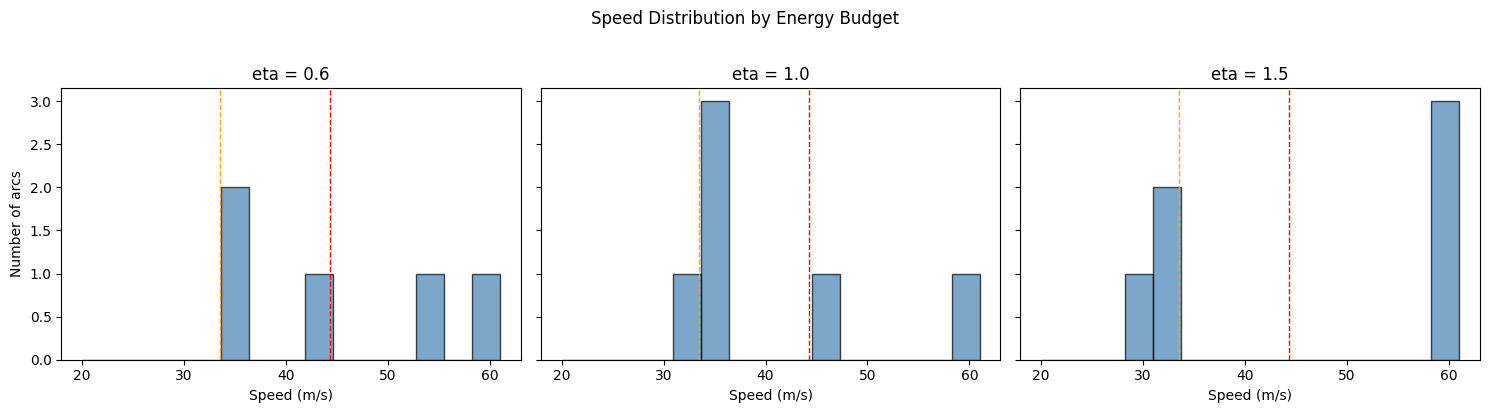

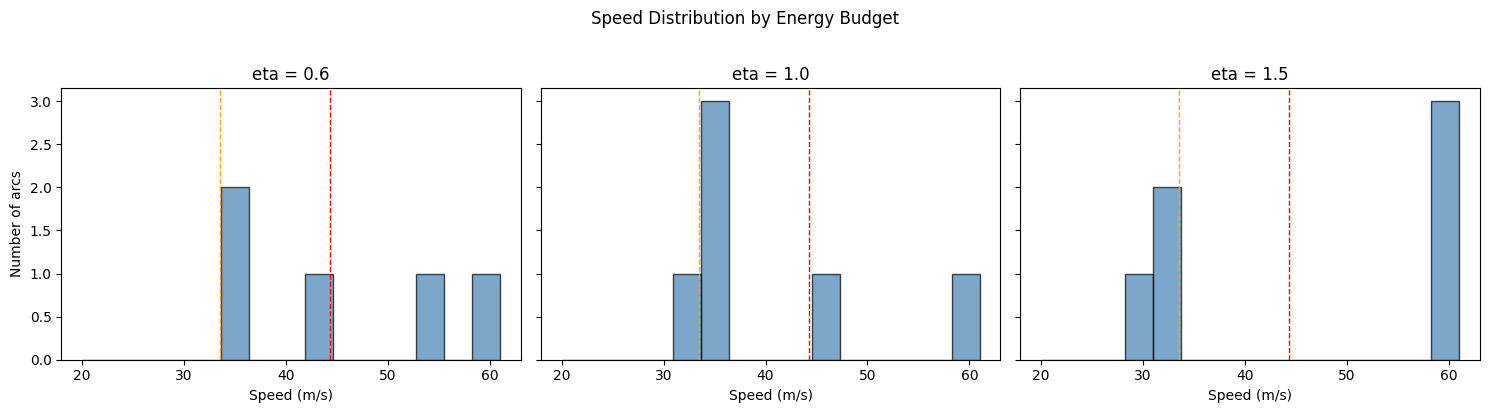

In [7]:
with gp.Env(empty=True) as env:
    env.setParam('OutputFlag', 0)
    env.start()

    instance, _, _ = make_instance(datasets["R101 (50)"])
    fig = speed_histogram_by_eta(instance, env, seed=SEED,
                                  eta_values=(0.6, 1.0, 1.50),
                                  time_limit=TIME_LIMIT)
fig

**Expected output: Figure 2 — Speed histograms by $\eta$**

Three overlaid histograms showing the distribution of edge speeds $v_{ij}$ for $\eta \in \{0.4, 0.8, 1.0\}$ on R101 (50).

**Purpose:** Reveal how the drone adapts its speed profile under different energy budgets:
- **Tight $\eta$ (0.4):** Speeds should cluster near $v_\text{opt}$ (minimum energy per meter) — the drone cannot afford to deviate.
- **Loose $\eta$ (1.0):** Speeds should spread across $[v_\text{min}, v_\text{max}]$ — the drone deliberately slows down on edges where late arrival improves information, or speeds up to reach time-sensitive nodes earlier.
- This figure directly illustrates the speed–energy–information coupling that distinguishes our model from classical orienteering.

## 7. Arrival Time Distribution by Slope

Where within time windows does the drone arrive?
- Positive slopes -> cluster near 1 (late arrival)
- Negative slopes -> cluster near 0 (early arrival)
- Zero slopes -> uniform (no preference)


Tour details — slope=random

--- Gurobi Solver Report ---
      Edge  Total Time (s)  Loiter Time (s)  Speed (m/s)  SOCP Energy (J)  Real Energy (J)  Energy %  Arrival Time (s)      Time Window      Slope
     0->45         1923.55           160.33        34.40      26605942.02      26606989.39   15.6403           1923.55 [1502.6, 1972.2]  31.733859
    45->12         1504.28             0.00        61.00      39509291.16      39509291.74   23.2246           3427.83 [2958.3, 3427.8]  46.799889
    12->40         1033.04           164.00        33.86      14279220.01      14279965.34    8.3941           4460.87 [3991.3, 4460.9]  41.630626
    40->22          563.48             0.00        58.38      14943541.79      13517619.93    7.9460           5024.35 [4554.8, 5024.3]  74.235302
    22->37         1737.39           115.65        34.54      24038070.11      24039124.86   14.1308           6761.74 [6292.2, 6761.7]   4.241438
    37->48         1455.65             0.00        46.82   

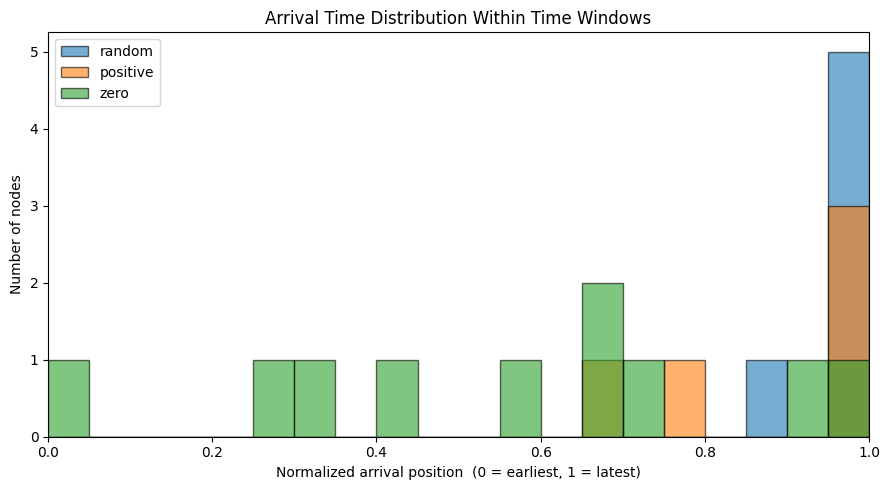

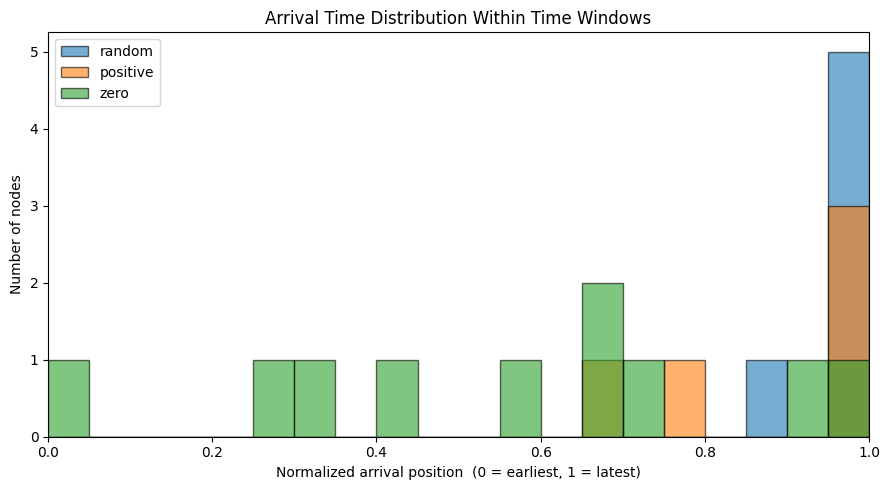

In [8]:
import matplotlib.pyplot as plt

test_path = datasets["R101 (50)"]
fig, ax = plt.subplots(figsize=(9, 5))

pairs = []
with gp.Env(empty=True) as env:
    env.setParam('OutputFlag', 0)
    env.start()

    for slope_type in ['random', 'positive', 'zero']:
        inst, _, _ = make_instance(test_path, slope=slope_type)
        res = solve_model_gurobi(inst, seed=SEED, time_limit=TIME_LIMIT,
                                 env=env, prune=False, stats=False)
        if res:
            pairs.append((slope_type, res))
            print(f"\n{'='*60}")
            print(f"Tour details — slope={slope_type}")
            print_table(inst, res)

    arrival_time_histogram(inst, pairs, ax=ax)

fig

# Yukarida negative, positive, ve zero slopelara bak.

**Expected output: Figure 3 — Arrival time distribution by slope regime**

Histogram of normalized arrival positions $(a_j - e_j) / (\ell_j - e_j)$ within time windows, grouped by slope regime (random, positive, zero) on R101 (50).

**Purpose:** Show that the solver exploits information dynamics to optimize arrival timing:
- **Positive slopes:** Arrivals cluster near 1.0 (late end of time window) — the drone delays to maximize information growth.
- **Random slopes:** Bimodal — early arrivals at nodes with negative slopes (decaying info), late arrivals at nodes with positive slopes.
- **Zero slopes:** Approximately uniform — arrival time is irrelevant, confirming that timing has no effect in the static case.

This is a key behavioral result: the model produces qualitatively different routing strategies depending on information dynamics, not just different objective values.

## 8. Single Run with Detailed Output

Detailed solver output and tour table for inspection.

In [9]:
instance, graph, uav = make_instance(datasets["R101 (50)"])

with gp.Env(empty=True) as env:
    env.setParam('OutputFlag', 1)
    env.start()
    res = solve_model_gurobi(instance, seed=SEED, time_limit=TIME_LIMIT,
                             env=env, prune=False, stats=True)
    print_table(instance, res)

Set parameter Username
Set parameter LicenseID to value 2761897
Academic license - for non-commercial use only - expires 2027-01-07
Set parameter Seed to value 42
Set parameter TimeLimit to value 600
Set parameter MIPFocus to value 1
Set parameter Threads to value 0
Set parameter Method to value 2
Set parameter ScaleFlag to value 2
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (mac64[arm] - Darwin 23.6.0 23G93)

CPU model: Apple M3 Pro
Thread count: 11 physical cores, 11 logical processors, using up to 11 threads

Non-default parameters:
TimeLimit  600
Method  2
ScaleFlag  2
MIPFocus  1
Seed  42

Optimize a model with 20606 rows, 15402 columns and 61406 nonzeros (Max)
Model fingerprint: 0x8491cc0d
Model has 100 linear objective coefficients
Model has 7650 quadratic constraints
Variable types: 12801 continuous, 2601 integer (2601 binary)
Coefficient statistics:
  Matrix range     [2e-02, 3e+00]
  QMatrix range    [1e+00, 1e+00]
  Objective range  [1e+03, 1e+06]
  Bounds range     [1e

**Expected output: Detailed tour table**

Full Gurobi log followed by a per-node tour table:

| Order | Node | Arrival (s) | TW start (s) | TW end (s) | Speed (m/s) | Distance (m) | Energy (J) | Info collected |
|-------|------|-------------|---------------|-------------|-------------|---------------|------------|----------------|
| 1 | depot | 0 | — | — | — | — | — | — |
| 2 | ... | ... | ... | ... | ... | ... | ... | ... |
| ... | ... | ... | ... | ... | ... | ... | ... | ... |
| k | depot | ... | — | — | — | — | — | — |

**Purpose:** Sanity check and detailed inspection of a single solution. Verify that time windows are respected, energy budget is not exceeded, and the speed/arrival patterns match expectations from the aggregate experiments above.

## 9. Solver Reproducibility

5 runs with different Gurobi seeds, same instance. Report mean/std of objective and time.

In [10]:
instance, _, _ = make_instance(datasets["R101 (50)"])

repro_rows = []
with gp.Env(empty=True) as env:
    env.setParam('OutputFlag', 0)
    env.start()

    for s in [42, 123, 456, 789, 1024]:
        res = solve_model_gurobi(instance, seed=s, time_limit=TIME_LIMIT,
                                 env=env, prune=False, stats=False)
        repro_rows.append({
            "Seed": s,
            "Objective": round(res["obj"], 2) if res else None,
            "Time (s)": round(res["solve_time"], 2) if res else None,
            "Gap (%)": f"{res['gap']*100:.4f}" if res and res.get("gap") is not None else "-",
            "Tour nodes": len(res["tour"]) - 2 if res and res.get("tour") else 0,
        })

df_repro = pd.DataFrame(repro_rows)
print(df_repro.to_string(index=False))
print(f"\nObjective: mean={df_repro['Objective'].mean():.2f}, std={df_repro['Objective'].std():.2f}")
print(f"Time:      mean={df_repro['Time (s)'].mean():.2f}, std={df_repro['Time (s)'].std():.2f}")

 Seed  Objective  Time (s) Gap (%)  Tour nodes
   42  144232.37      2.36  0.0000           6
  123  144232.37     13.21  0.0000           6
  456  144232.37      1.26  0.0000           6
  789  144232.37      1.16  0.0000           6
 1024  144232.37      9.21  0.0000           6

Objective: mean=144232.37, std=0.00
Time:      mean=5.44, std=5.47


**Expected output: Table 5 — Solver reproducibility**

| Seed | Objective | Gap (%) | Time (s) | Tour nodes |
|------|-----------|---------|----------|------------|
| 42 | — | — | — | — |
| 123 | — | — | — | — |
| 456 | — | — | — | — |
| 789 | — | — | — | — |
| 1024 | — | — | — | — |
| **mean ± std** | — | — | — | — |

**Settings:** R101 (50), $\eta = 1$, random slopes, time limit = 600s.

**Purpose:** Verify that Gurobi's internal randomization (thread scheduling, tie-breaking) does not produce large variance in solution quality. If the instance is solved to optimality, all seeds should give the same objective. If the time limit is hit, small variance is acceptable; large variance would indicate solver instability and suggest that results should be averaged over multiple seeds.